In [1]:
import numpy as np
import matplotlib.pyplot as plt
from deepOnet_definitions import *
from FFEM_building_blocks import Mesh


# Automatic generation of source functions and the Poisson solution algorithm
# For the moment I keep a small number of modes and max frequencies, 
# otherwise the dimensionality of the training dataset rises too quickly and the training becomes mofre complicated
# I use the same function in the create_training_dataset.py file

def generate_source_function(num_modes:int=3, max_freq:int=4, max_amplitude = 1.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)
    ky = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function

# First try a "basic" deepOnet

In [2]:
x_branch = np.linspace(-1, 1, 20)
y_branch = np.linspace(-1, 1, 20)
X_branch, Y_branch = np.meshgrid(x_branch, y_branch, indexing="ij")
coords_branch = np.stack([X_branch.ravel(), Y_branch.ravel()], axis=-1)


don = deepOnet_v1(x_coords_for_branch = coords_branch, N_nodes_branch = 200, N_nodes_trunk = 200, latent_dimension = 200)


don.fit_from_npz('data/dataset.npz', 5000)

Y std across samples: 0.04507255181670189
Y std across points: 0.036380499601364136
Epoch [100/5000], Loss: 0.0012, Loss eval: 0.0012
prediction std across samples: 0.03856900334358215
prediction std across points: 0.017430594190955162
Epoch [200/5000], Loss: 0.0009, Loss eval: 0.0009
prediction std across samples: 0.039153970777988434
prediction std across points: 0.017551206052303314
Epoch [300/5000], Loss: 0.0008, Loss eval: 0.0008
prediction std across samples: 0.039881013333797455
prediction std across points: 0.019732847809791565
Epoch [400/5000], Loss: 0.0007, Loss eval: 0.0007
prediction std across samples: 0.040512390434741974
prediction std across points: 0.021684441715478897
Epoch [500/5000], Loss: 0.0007, Loss eval: 0.0007
prediction std across samples: 0.041148096323013306
prediction std across points: 0.02340550720691681
Epoch [600/5000], Loss: 0.0006, Loss eval: 0.0006
prediction std across samples: 0.041726626455783844
prediction std across points: 0.02478443644940853
E

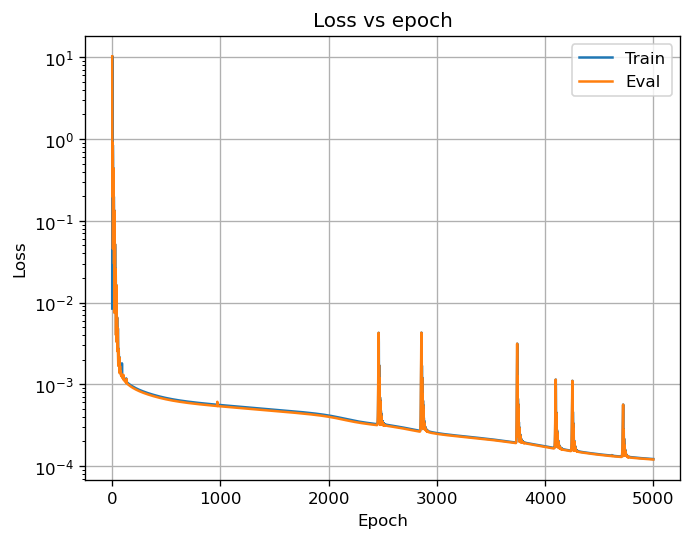

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_3798/247360811.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


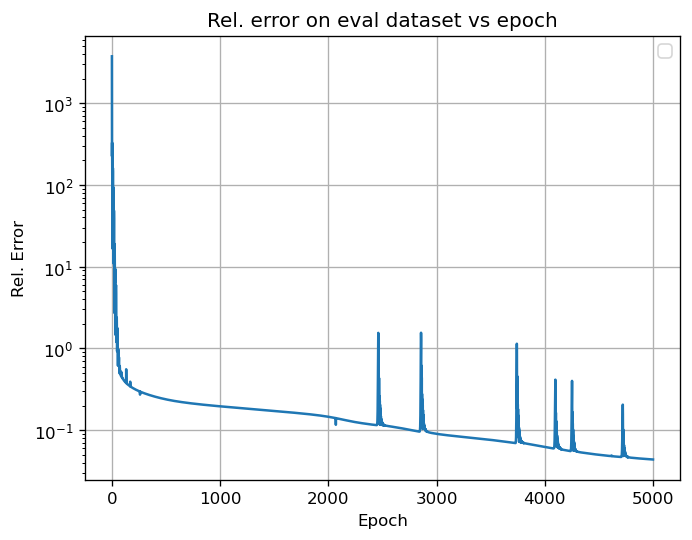

In [3]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don.epochs, don.losses, label = "Train")
plt.semilogy(don.epochs, don.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(don.epochs, don.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

In [4]:
# TO DO: more quantitative tests on a control dataset

# TO DO: try GRF for lower effective dimensionality

# Now try Fourier encoding

based on https://arxiv.org/pdf/2509.12344.

Y std across samples: 0.04507255181670189
Y std across points: 0.036380499601364136
Epoch [100/5000], Loss: 0.0005, Loss eval: 0.0005
prediction std across samples: 0.043148770928382874
prediction std across points: 0.029573457315564156
Epoch [200/5000], Loss: 0.0004, Loss eval: 0.0004
prediction std across samples: 0.0433778390288353
prediction std across points: 0.029931487515568733
Epoch [300/5000], Loss: 0.0003, Loss eval: 0.0003
prediction std across samples: 0.04345545917749405
prediction std across points: 0.030349498614668846
Epoch [400/5000], Loss: 0.0003, Loss eval: 0.0003
prediction std across samples: 0.04350859671831131
prediction std across points: 0.030767390504479408
Epoch [500/5000], Loss: 0.0003, Loss eval: 0.0003
prediction std across samples: 0.043565455824136734
prediction std across points: 0.031170787289738655
Epoch [600/5000], Loss: 0.0002, Loss eval: 0.0002
prediction std across samples: 0.04362912103533745
prediction std across points: 0.031564440578222275
Epo

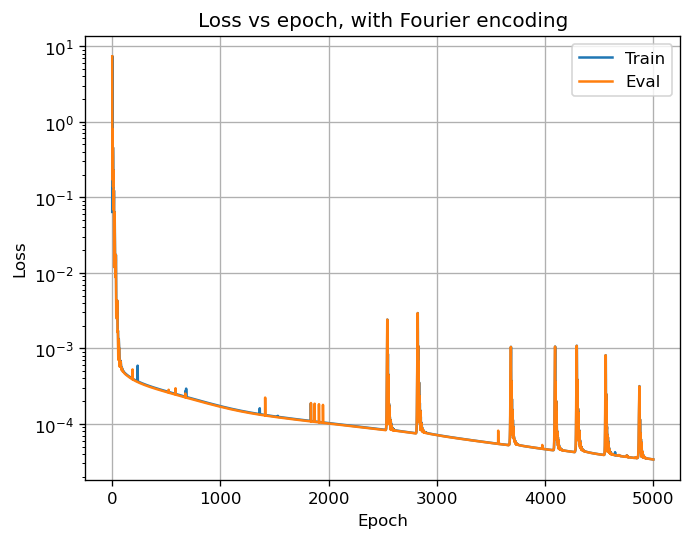

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_3798/3493936392.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


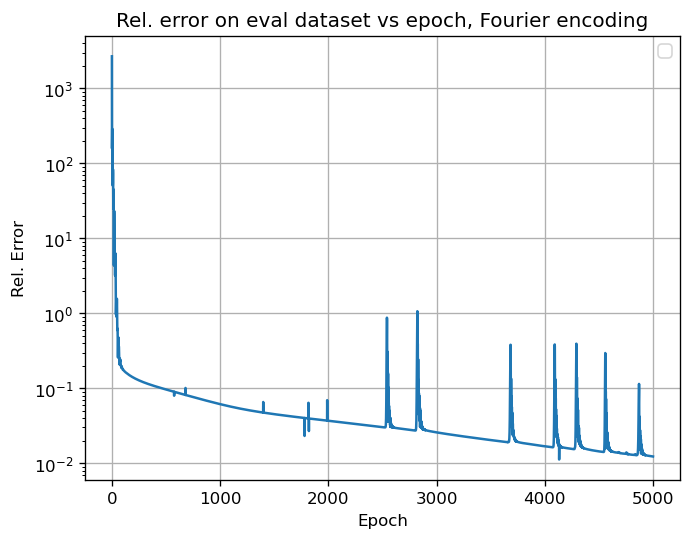

In [5]:
x_branch = np.linspace(-1, 1, 20)
y_branch = np.linspace(-1, 1, 20)
X_branch, Y_branch = np.meshgrid(x_branch, y_branch, indexing="ij")
coords_branch = np.stack([X_branch.ravel(), Y_branch.ravel()], axis=-1)

don_fourier = deepOnet_fourier_embedded_v2(x_coords_for_branch = coords_branch, N_nodes_branch = 200, N_nodes_trunk = 200, latent_dimension = 200)

don_fourier.fit_from_npz('data/dataset.npz', 5000)

plt.figure(dpi = 120)
plt.title("Loss vs epoch, with Fourier encoding")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don_fourier.epochs, don_fourier.losses, label = "Train")
plt.semilogy(don_fourier.epochs, don_fourier.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch, Fourier encoding")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(don_fourier.epochs, don_fourier.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


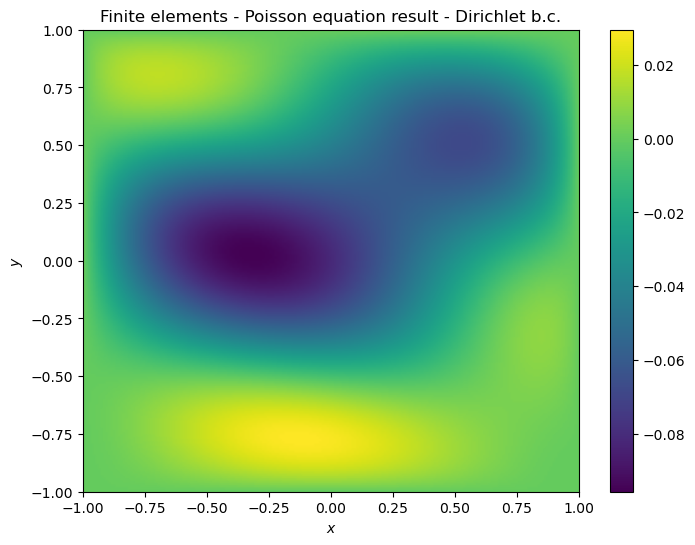

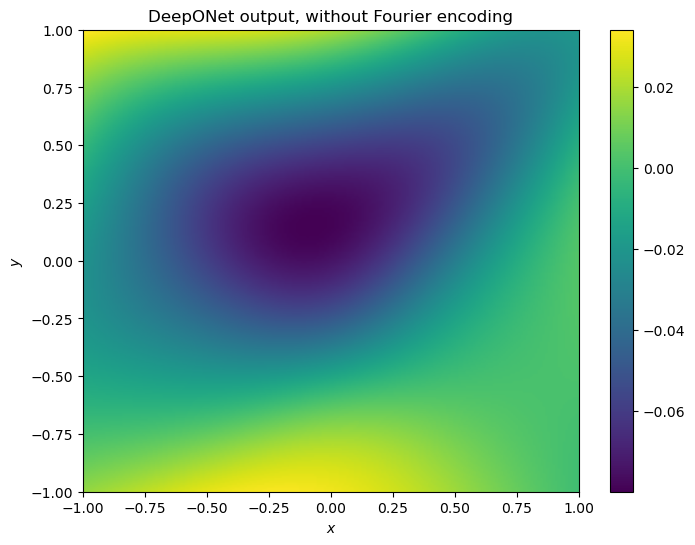

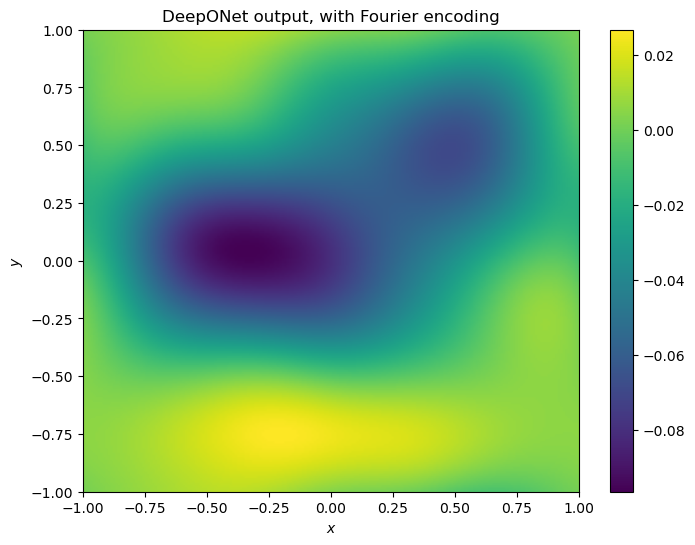

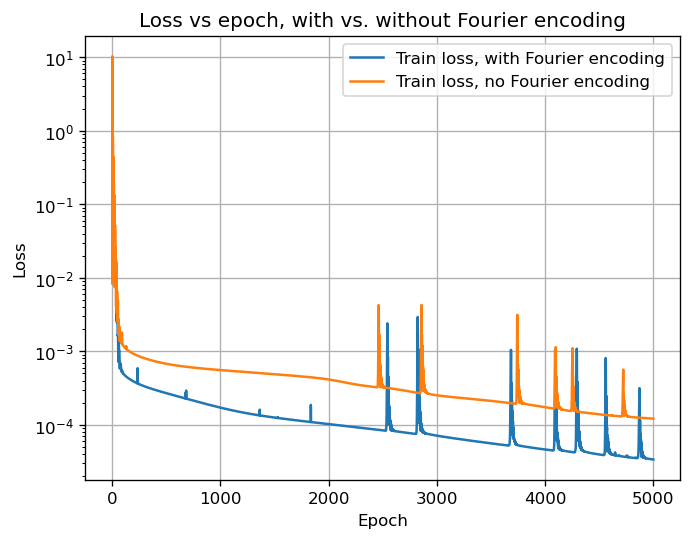

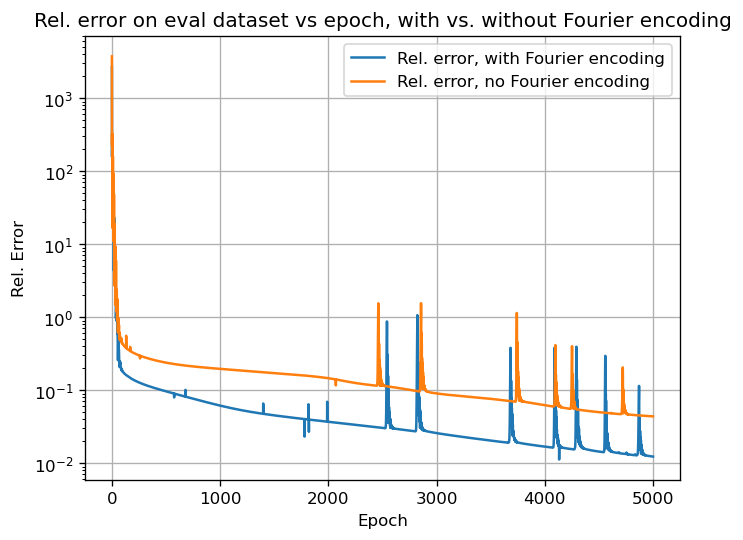

In [12]:
# now test visually on a randomly generated function

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()
# coordinates of mesh points 
X, Y = np.meshgrid(x, y, indexing="ij")
coords = np.stack([X.ravel(), Y.ravel()], axis=-1)
diri = lambda x, y: 0

func = generate_source_function()
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
plt.figure(figsize=(8, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


result_don = don.map_function_to_output_at_points(func, np.array(coords)).squeeze(0).detach().cpu().numpy().reshape(200,200)
# detach to get rid of the tensor structure
# squeeze(0) to go from dimension (1, N) to (N)


plt.figure(figsize=(8, 6))
plt.imshow(result_don, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('DeepONet output, without Fourier encoding')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

result_don_fourier = don_fourier.map_function_to_output_at_points(func, np.array(coords)).squeeze(0).detach().cpu().numpy().reshape(200,200)
# detach to get rid of the tensor structure
# squeeze(0) to go from dimension (1, N) to (N)


plt.figure(figsize=(8, 6))
plt.imshow(result_don_fourier, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('DeepONet output, with Fourier encoding')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


plt.figure(dpi = 120)
plt.title("Loss vs epoch, with vs. without Fourier encoding")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don_fourier.epochs, don_fourier.losses, label = "Train loss, with Fourier encoding")
plt.semilogy(don.epochs, don.losses, label = "Train loss, no Fourier encoding")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch, with vs. without Fourier encoding")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(don_fourier.epochs, don_fourier.rel_errors_eval, label = "Rel. error, with Fourier encoding")
plt.semilogy(don.epochs, don.rel_errors_eval, label = "Rel. error, no Fourier encoding")
plt.legend()
plt.grid()
plt.show()


# Remarks

- if one wanted one could add more frequencies to the encoding, i.e. sin(k * 2pi x)
- training with lr = 0.001 works much better (stabler and much closer results to desired output after the same number of iterations) than training with lr = 0.01 
- Fourier encoding **significantly improves** training performance and hence the results after a fixed number of iterations. especially in the first 2000 epochs
- As expected, with both approaches (but even more so with the basic one) the prediction rapidly deteriorates if I test the models with an input function having higher dimensionality than the input functions in the training dataset


# To do

- Try with set of input functions with higher frequencies. There Fourier encoding might play an even more drastic role (add even more modes?)
- Implement a scheduler to improve convergence, see for instance torch.optim.lr_scheduler.ReduceLROnPlateau

use standard libraries for comparison?